In [1]:
import sys
import os

# Add the parent directory to sys.path so we can import znet without installing it
sys.path.append(os.path.abspath('..'))

import torch
from znet import ZNet, SourceNode, MixingNode, StackNode
import matplotlib.pyplot as plt

print("znet imported successfully")

znet imported successfully


In [ ]:
muA= SourceNode(key="mu_A")
muB = SourceNode(key="mu_B")
phase_aStack = StackNode([MixingNode(muA, enthalpy=1000), muB])
phase_a = MixingNode([phase_aStack])
phase_bStack = StackNode([muA, MixingNode(muB, enthalpy=1000)])
phase_b = MixingNode([phase_bStack])

In [3]:
mu_vals = torch.linspace(-20000, 20000, 1000).unsqueeze(1) # Shape (100, 1)
inputs = {
    "mu_A": mu_vals, 
    "mu_B": -mu_vals, 
}

C:\Users\wellandm\AppData\Local\Temp\ipykernel_20232\1333606475.py:31: RuntimeWarning: divide by zero encountered in log
  ha_ideal = 8.314*293.15*(xa*(1000/(8.314*293.15)+np.log(xa)) + (1-xa)*np.log(1-xa))
C:\Users\wellandm\AppData\Local\Temp\ipykernel_20232\1333606475.py:31: RuntimeWarning: invalid value encountered in multiply
  ha_ideal = 8.314*293.15*(xa*(1000/(8.314*293.15)+np.log(xa)) + (1-xa)*np.log(1-xa))


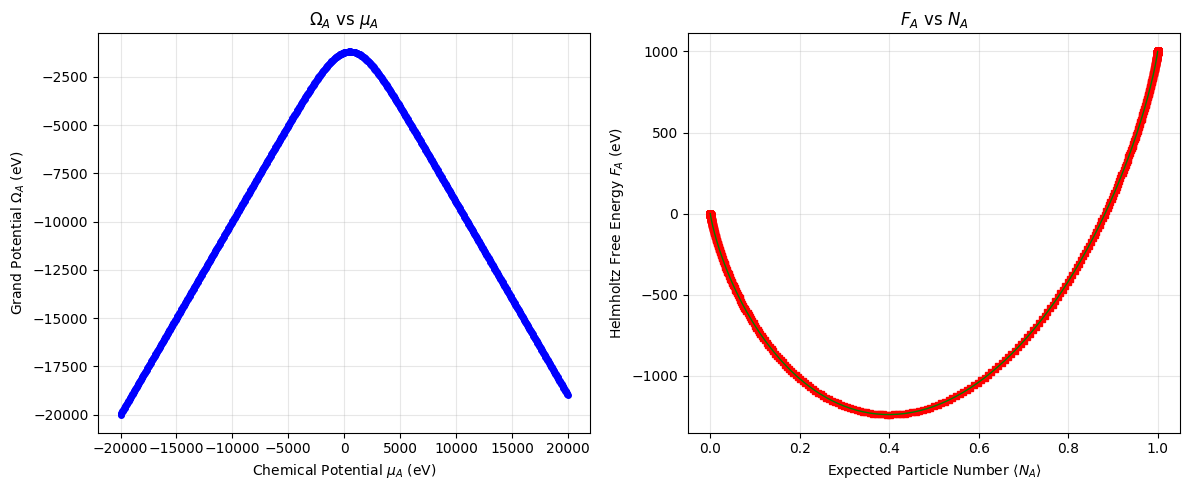

In [4]:
omega_a = ZNet(phase_a)
omega_a_vals = omega_a(inputs).detach().numpy().flatten()
mu_a_axis = inputs["mu_A"].detach().numpy().flatten()


helmholtz_a_vals, N_a_vals = omega_a.to_Helmholtz(inputs)
# Extract the particle number for the key 'mu_A'
N_a_axis = N_a_vals['mu_A'].detach().numpy().flatten()
helmholtz_a_vals = helmholtz_a_vals.detach().numpy().flatten()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Grand Potential vs Chemical Potential
ax1.plot(mu_a_axis, omega_a_vals, 'b-', linewidth=2, marker='o', markersize=4)
ax1.set_xlabel(r'Chemical Potential $\mu_A$ (eV)')
ax1.set_ylabel(r'Grand Potential $\Omega_A$ (eV)')
ax1.set_title(r'$\Omega_A$ vs $\mu_A$')
ax1.grid(True, alpha=0.3)

# Plot 2: Helmholtz Free Energy vs Particle Number
if len(N_a_axis) > 0:
    ax2.plot(N_a_axis, helmholtz_a_vals, 'r-', linewidth=2, marker='s', markersize=4)
    ax2.set_xlabel(r'Expected Particle Number $\langle N_A \rangle$')
    ax2.set_ylabel(r'Helmholtz Free Energy $F_A$ (eV)')
    ax2.set_title(r'$F_A$ vs $N_A$')
    ax2.grid(True, alpha=0.3)

import numpy as np
xa = N_a_axis
ha_ideal = 8.314*293.15*(xa*(1000/(8.314*293.15)+np.log(xa)) + (1-xa)*np.log(1-xa))
ax2.plot(N_a_axis, ha_ideal, 'g-', linewidth=1)

plt.tight_layout()
plt.show()

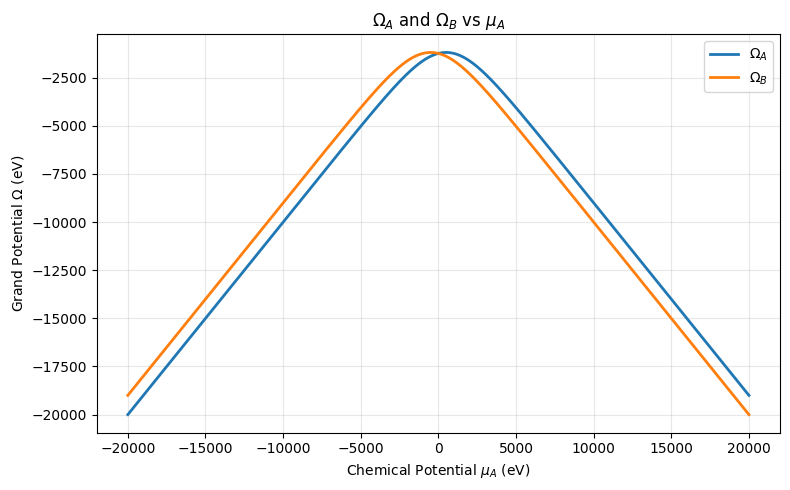

In [5]:
omega_b = ZNet(phase_b)

omega_a_vals = omega_a(inputs).detach().numpy().flatten()
omega_b_vals = omega_b(inputs).detach().numpy().flatten()
mu_a_axis = inputs["mu_A"].detach().numpy().flatten()

plt.figure(figsize=(8, 5))
plt.plot(mu_a_axis, omega_a_vals, label=r'$\Omega_A$', linewidth=2)
plt.plot(mu_a_axis, omega_b_vals, label=r'$\Omega_B$', linewidth=2)
plt.xlabel(r'Chemical Potential $\mu_A$ (eV)')
plt.ylabel(r'Grand Potential $\Omega$ (eV)')
plt.title(r'$\Omega_A$ and $\Omega_B$ vs $\mu_A$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
ideal_mixed = MixingNode(sub_nodes=[StackNode([phase_a, phase_b])], scale=1e-5)
omega = ZNet(ideal_mixed)

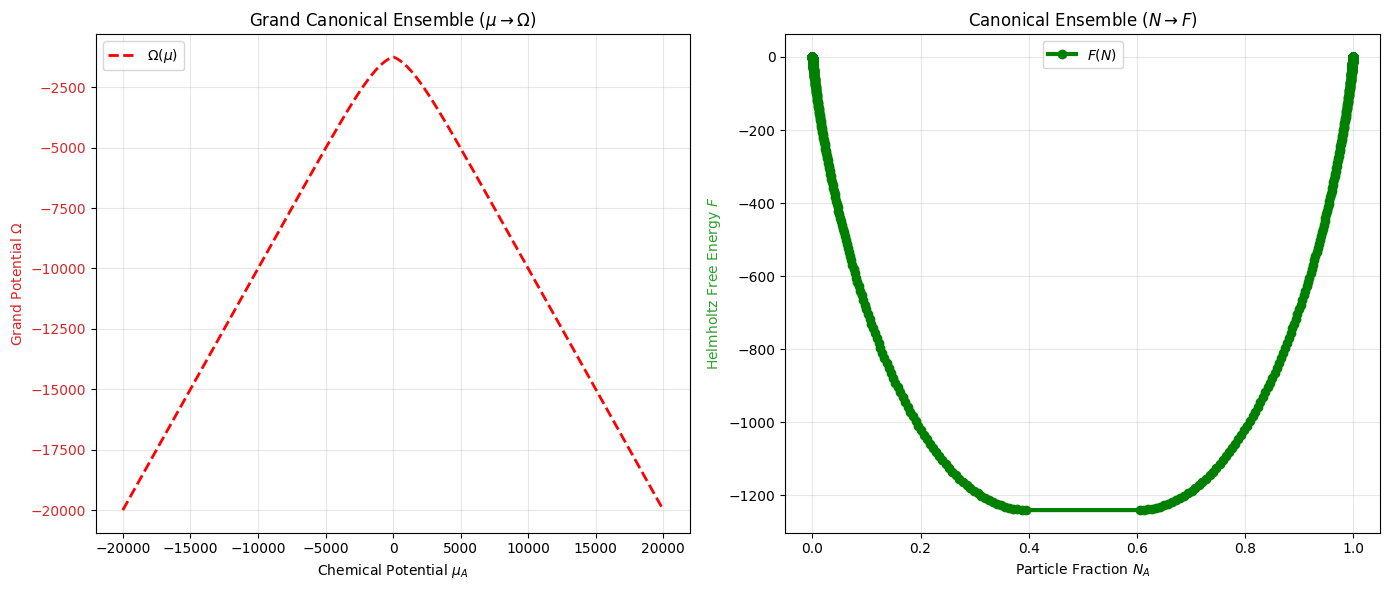

In [7]:
import matplotlib.pyplot as plt
# 5. Visualization
Helmholtz_F, N_counts = omega.to_Helmholtz(inputs)
Omega = omega(inputs)

# Flatten() ensures everything is a 1D array for plotting
mu_axis = inputs['mu_A'].detach().numpy().flatten()
y_omega = Omega.detach().numpy().flatten()
y_helmholtz = Helmholtz_F.detach().numpy().flatten()
y_NA = N_counts['mu_A'].detach().numpy().flatten()

# Note: We do not simplify sorting here because F(N) needs N to be the x-axis, 
# and mu might not be monotonic with N in complex systems (though here it is).
sort_idx = mu_axis.argsort()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Grand Potential vs Chemical Potential (Natural Variables)
ax1.set_xlabel(r'Chemical Potential $\mu_A$')
ax1.set_ylabel(r'Grand Potential $\Omega$', color='tab:red')
ax1.plot(mu_axis[sort_idx], y_omega[sort_idx], 'r--', linewidth=2, label=r'$\Omega(\mu)$')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title(r'Grand Canonical Ensemble ($\mu \to \Omega$)')

# Plot 2: Helmholtz Free Energy vs Particle Number (Conjugate Variables)
# Ideally F is plotted against its natural variable N_A
# Sort by N_A for a clean line
sort_N = y_NA.argsort()

ax2.set_xlabel(r'Particle Fraction $N_A$')
ax2.set_ylabel(r'Helmholtz Free Energy $F$', color='tab:green')
ax2.plot(y_NA[sort_N], y_helmholtz[sort_N], 'g-', linewidth=3, label=r'$F(N)$', marker='o')
ax2.legend(loc='upper center')
ax2.grid(True, alpha=0.3)
ax2.set_title(r'Canonical Ensemble ($N \to F$)')

plt.tight_layout()
plt.show()